In [15]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
# Step 2: Load Dataset

housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data, housing.target.rename("HousePrice")],
    axis=1
)

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [17]:
# Step 3: Separate Features and Target

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [18]:
# Step 4: Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# Step 5: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Step 6: Train Multiple Models

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

In [21]:
# Step 7: Model Evaluation

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T

print(results_df)

                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732


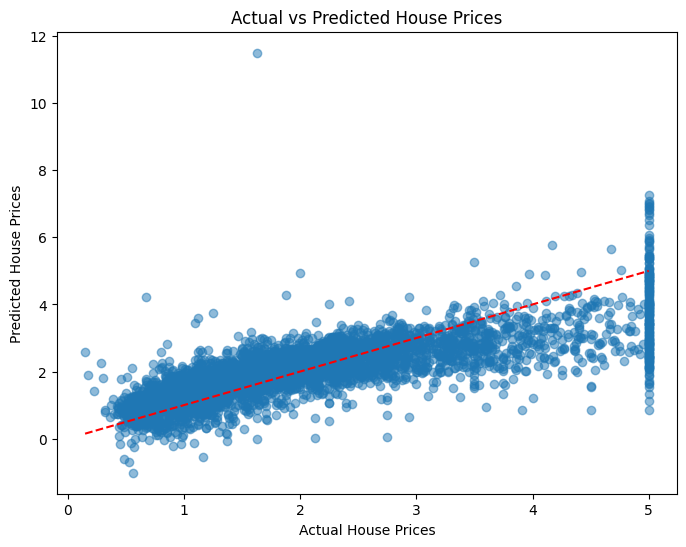

In [25]:
# Step 8: Visual Validation using Best Model

best_model = LinearRegression()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

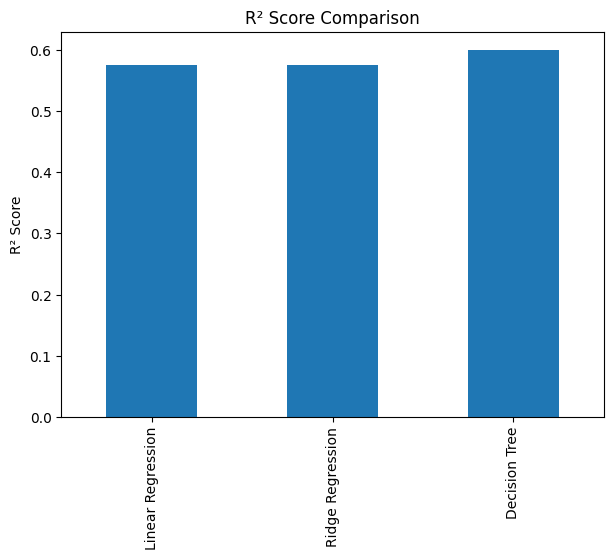

In [24]:
results_df["R2 Score"].plot(
    kind="bar",
    figsize=(7,5),
    title="R² Score Comparison"
)

plt.ylabel("R² Score")
plt.show()

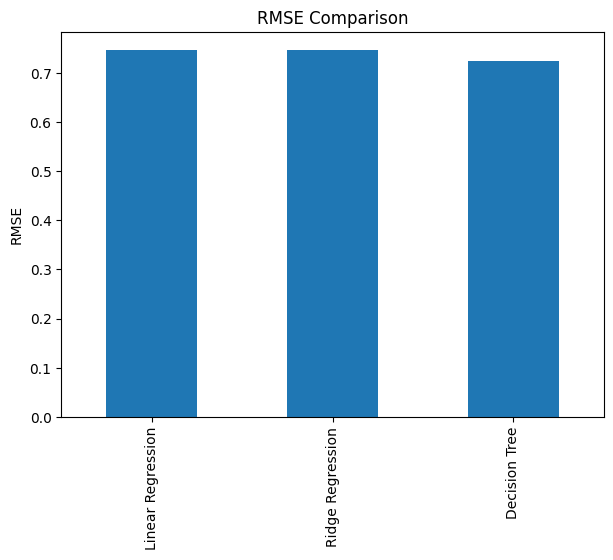

In [26]:
results_df["RMSE"].plot(
    kind="bar",
    figsize=(7,5),
    title="RMSE Comparison"
)

plt.ylabel("RMSE")
plt.show()